# Assignment 1: k-means Clustering
## Group 8
#### Members: Anika Viado, Troy Dela Rosa, Vance Castro, and Ben Thompson

In [27]:
# fix Windows memory leak warning from KMeans
import os
os.environ["OMP_NUM_THREADS"] = "1"
# imports 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# **Data Prep**

In [28]:
# load dataset in df
df = pd.read_csv("Country-data.csv")
# print the header 
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


### Summarize the data 

In [29]:
# summarize data
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


The dataset contains data in 167 countries using nine socio-economic and health related factors.

### Column Summary 

**child_mort**:  This column shows the mortality rate of children under 5 years old per 1,000 live births. It has a mean of 38.3 and a median of 19.30, and values ranging from 2.6 and 208. The gap between the mean and medians tells us that some countries have higher child mortatlity than most of the countries in the dataset.<br>

**exports**:  This column shows the percentage of the GDP of exported good and services. It has an average of 41.11% and a median of 35.00%, with values ranging from 0.109% to 200%. This tells us that exports contribute differently to each country's economy.

**health**:  This column shows the percentage of GDP spent on healthcare. It has a mean of 6.82% and median of 6.32% ranging from 1.81% and 17.9%. The small difference between the mean and median suggests that this data is more balanced than the other variables in this dataset.

**imports**:  This column is the percentage GDP of imported goods and services. The values range from 0.0659% to 174%, tell us that countries have very different levels of reliance on imports. The mean of 46.89% and median of 43.30% shows that import levels are similar across many countries.

**income**:  This is the average salary per person in a country. With a mean of 17,144.69 and median of 9,960, with a huge range of 609 to 125,000. This shows us that a small portion of countries actually have higher incomes than the majority.

**inflation**:  This shows how fast prices increase in the economy. It has a mean of 7.78%  ranging from -4.21% to 104%. This wide range tells us that some countries experienced different levels of inflation, with some countries having higher values.

**life_expec**:  This shows the number of years a newborn is expected to live. Has a mean of 70.56 years and a median of 73.10 years with values ranging from 32.1 to 82.8 years, which shows very different life expectancy across different countries.

**toal_fer**:  This column shows the avreage number of children a woman is expected to have. It has a mean of 2.95 and median of 2.41 ranging from 1.15 to 7.49. This shows that the fertility rate varies across the countries as well.

**gdpp**:  GDP per person, or per capita. This column has a mean of 12,964.16 and median of of 4,660 and values ranging from 231 to 105,000. This large difference between the mean and median shows that smaller number of countries have higher GDP per capita than most countries in this dataset. 

The summary statistics of the countries in this dataset shows that they have different ecnonomic, health, and demographic conditions. There are some variables that have large difference between the mean and median, which means there are some countries with much higher or lower values than others. For example, child mortatlity, income, and GDP per capita all show wide ranges, suggesting that some countries are much more developed or have much worse health outcomes than others. Life expectancy, inflation, and fetility rates also cary across countries, which shows clear differences in living standards, economic stability, and etc. These differences are useful because they show meaningful patterns in the dara and amek it possible to group countries with similar characteristics during clustering. These stats provide valuable insights because they hightlihgt how different eacg country is accross the variables in this dataset.

# **Data Cleaning**

### Check data types and missing values

In [30]:
# check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Using df.info(), it shows that the dataset has 167 entries and 10 columns and that there are 167 non-null values, so there are no missing values in this dataset. The datatypes makes sense for what each column is telling us. Country is stored as object (tex), which makes sense because it stores country names. The other nin columns are all float64 or int64, which is correct since they all have numeric measurements

### Check for duplicate rows

In [31]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 0


After running df.duplicated().sum(), there are no duplicate rows for this dataset since it returned 0. This means that there are no values that needs to be dropped or cleaned in regards of this.

### Check for missing values 

In [32]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

After running df.isnull().sum(), there are no missing values in this dataset since every column is returning 0. No columns needs to be dropped or filled in across the 167 rows and 10 columns

# **Drop 'country' and Store in a Seperate Dataframe**

In [33]:
# define country column in a variable 
countries = df['country']
# drop the column
df = df.drop(columns=['country'])

### Corelation heatmap

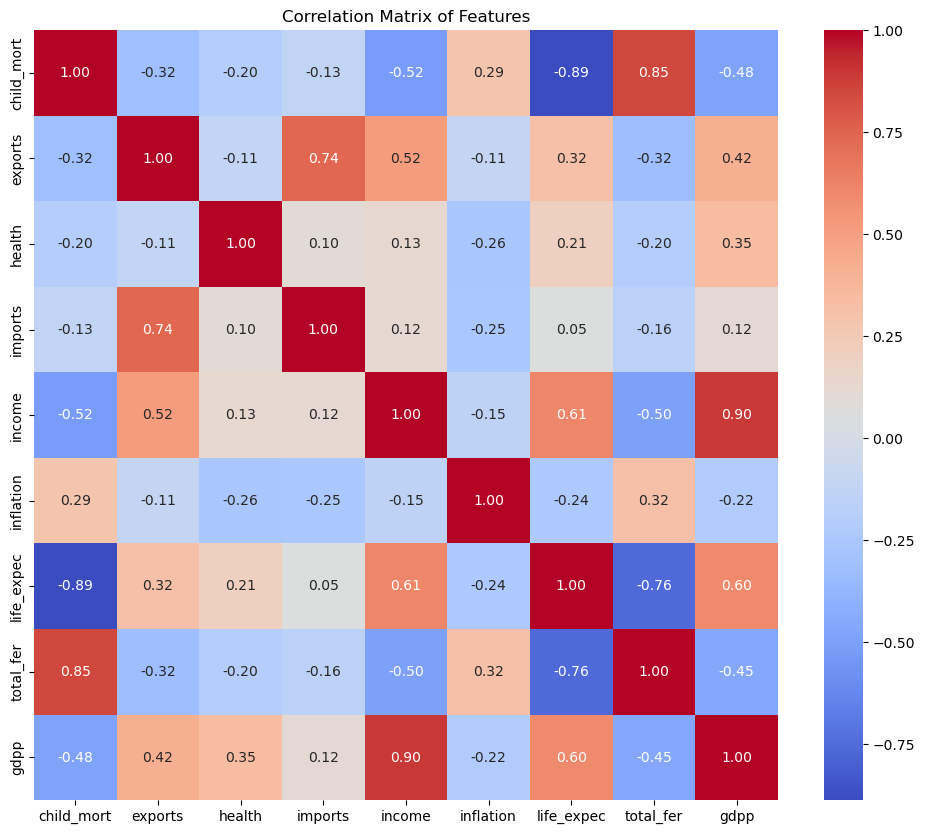

In [34]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### **Observations of Heatmap:**

<ul>
  <li>Child mortality naturally has a strong negative correlation with life expectancy, and a strong positive correlation to total fertility. The reasoning behind this can be seen in our financial attributes, which are negatively correlated across the board (other than inflation, but that is a "negative" financial feature. This shows that financial instability is a major factor in child mortality.</li>
  <li>In countries with lower GDP, an assumption might be made that more children would cause a financial strain which could effect the care of each individual child which may deter individuals from having more children. However, there is a negative correlation between GDP and total fertility. This could be a case of need vs. want, people in lower GDP countries may need the support of a larger family structure to sustain themselves and their industries, and so have more children on average while people in higher GDP countries have less financial pressure on the decision to have children.
  <li>Life expectancy and fertility may both seem to be signs of healthy development, but they actually have a heavy negative correlation. The reason behind this might be due partially to our previous insight, that higher fertility may mean more financial instability in a country, which may cause lower research and supplies in fields such as health and medicine. As well, the higher a population is the less time a country can spend attending to each individual persons needs.</li>
  <li>As imports and exports decrease, inflation increases. This is most likely because with less movement of product in and out of a country, the economy becomes static. With the promise of new resources replenishing current product, the value of all product increases due to a sensation whether true or not that these items are in limited supply.</li>
  <li>Income and life expectancy are positively correlated at 0.61. Assuming that finances are standarized to one currency it is surprising this correlation is not stronger. For most cases, finances can get you out of situations that lead to death other than terminal illness and other inescapable factors. This leaves aspects of the country itself such as flora and fauna, political state, and tempermant to most likely be part of the cause.</li>
</ul>

### Pairplot

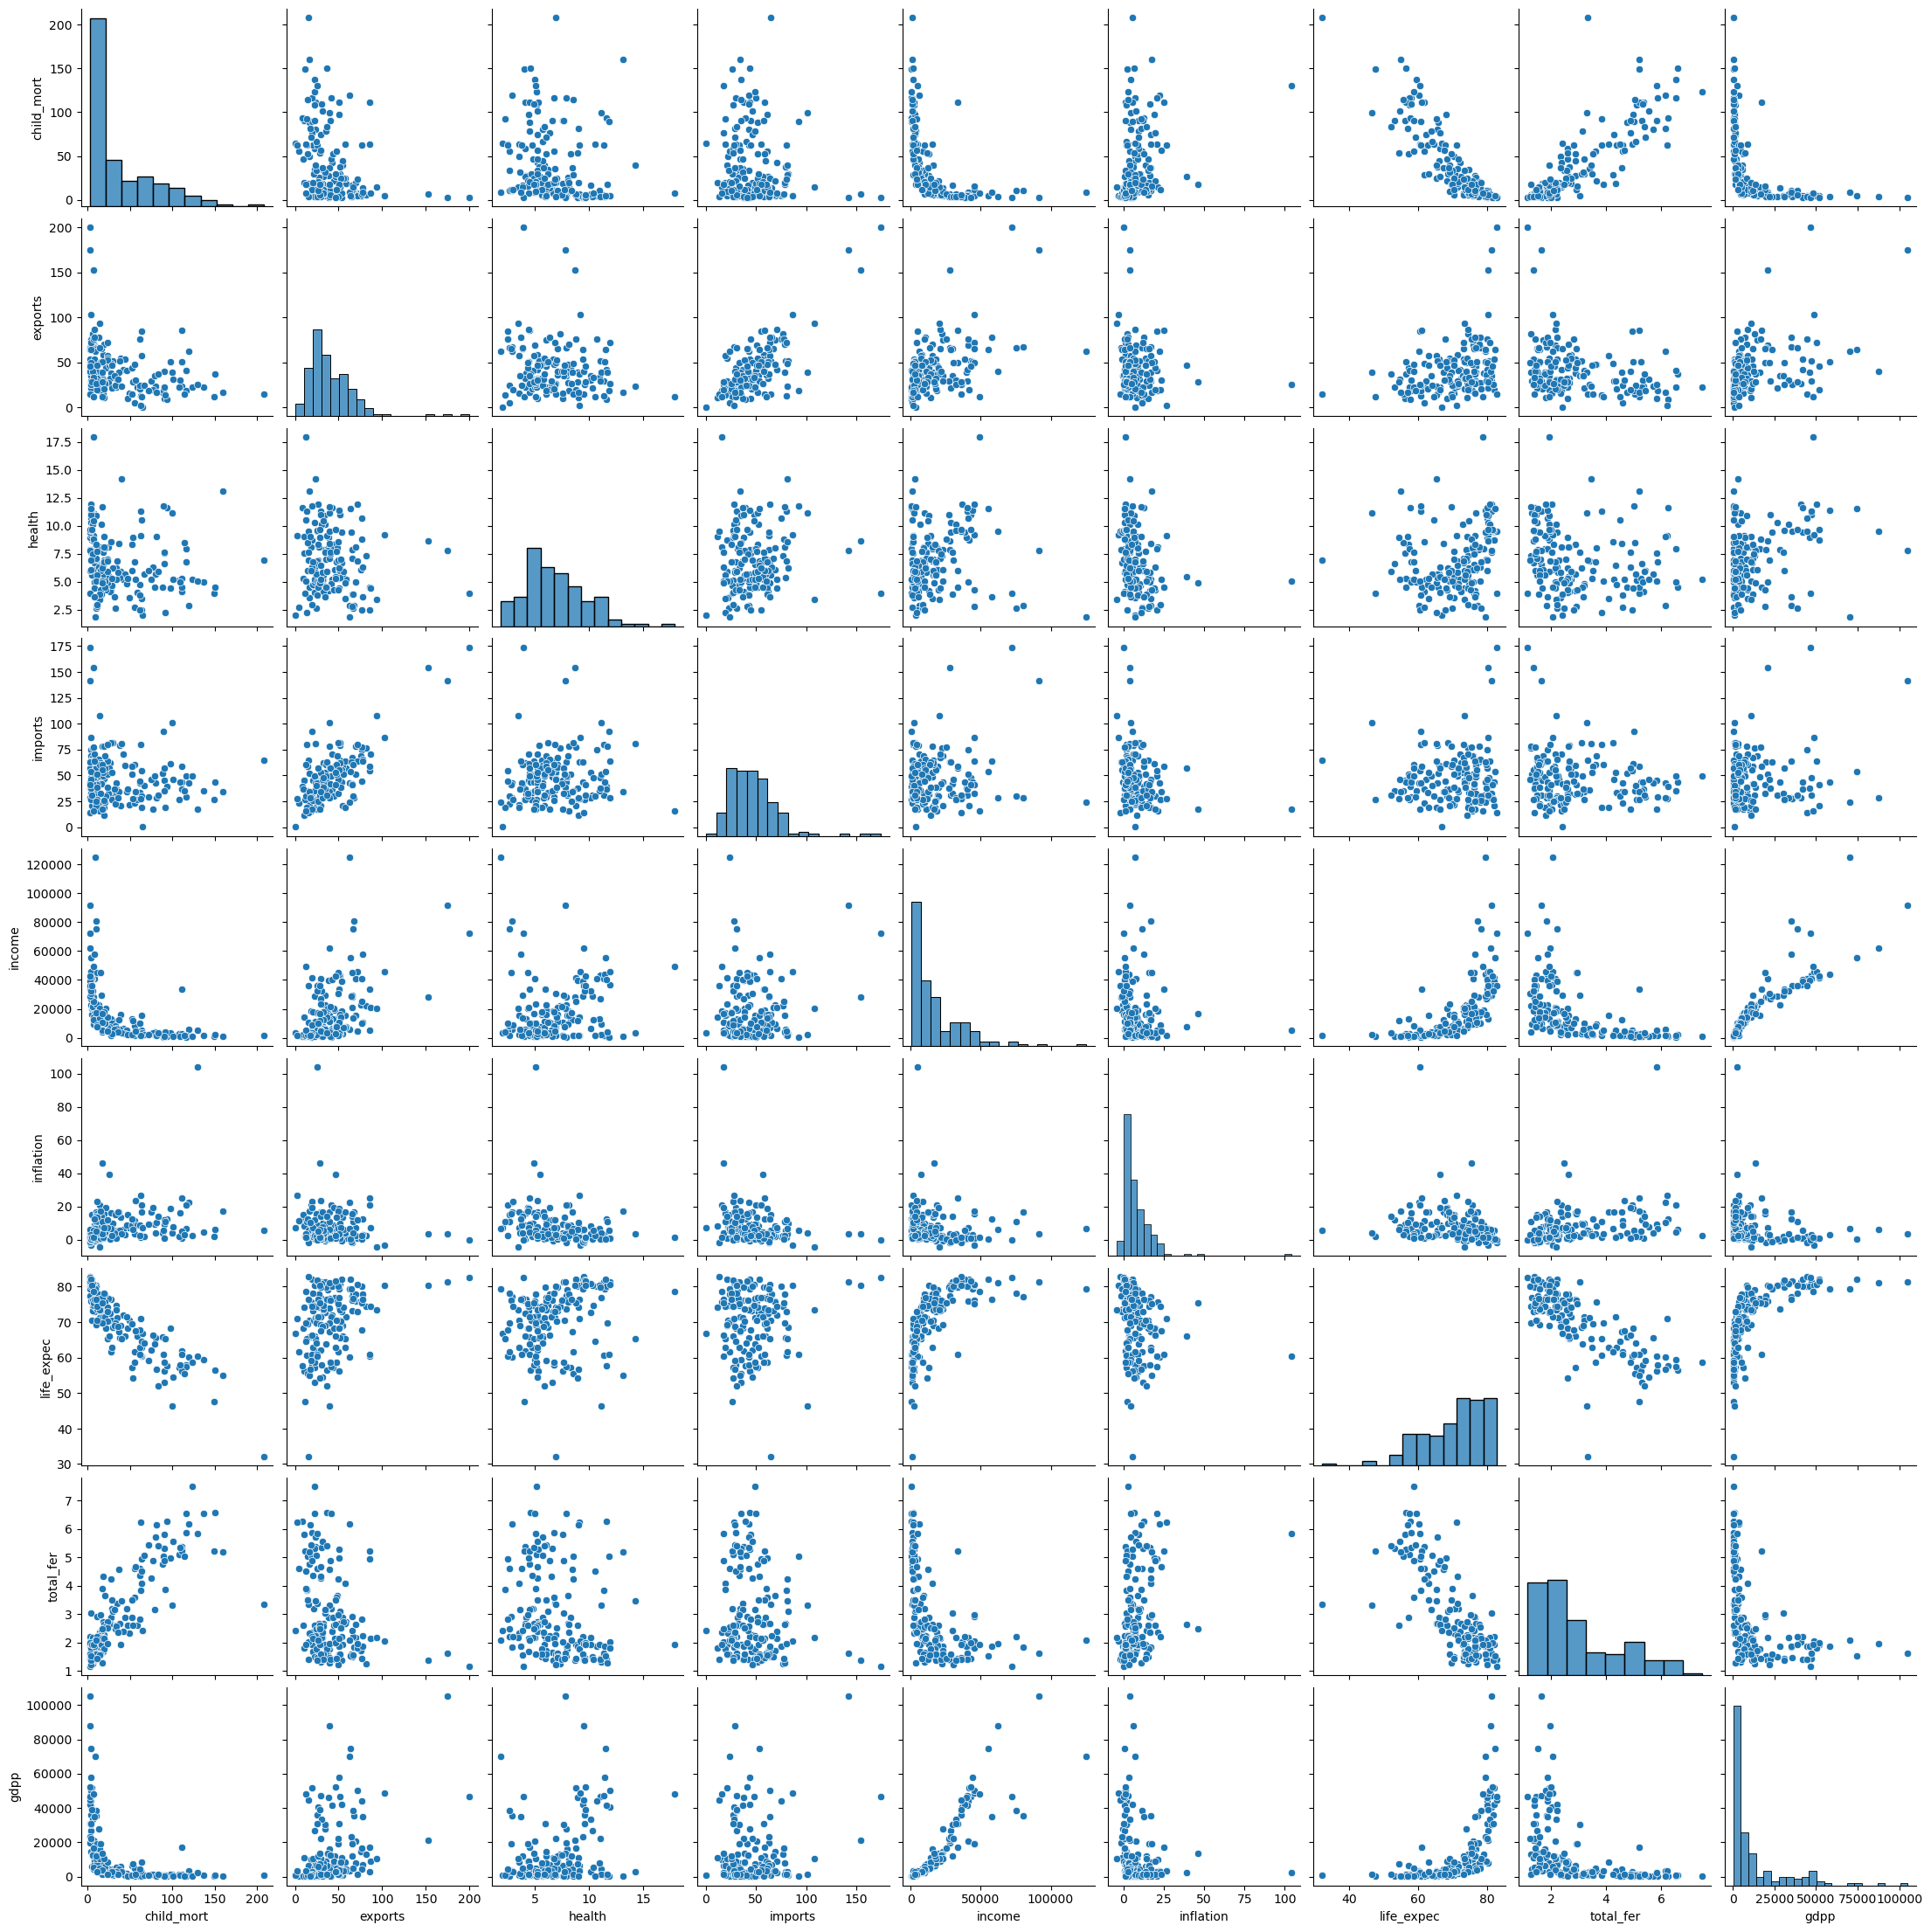

In [35]:
sns.pairplot(df)
plt.show()

### **Observations of Pairplot:**

<ul>
  <li>Child mortality is of an extremely skewed distribution, a small selection of countries having far higher fatality rates than a majority of the others. This almost certainly belongs to countries that are in the midst of war/conflict, where the care of children can be interrupted rapidly.</li>
  <li>A significant portion of the scatterplots contain an elbow point similar to what is seen when selecting the amount of clusters for the K-means clustering method. Similar to how it signifies the beginning of extreme overfitting in the elbow method, these scatterplots show a general disparity between a certain select group of countries and the rest being mostly uniform compared to that group. This is often in context of the financial features, overall displaying the difference the global superpowers and other countries.</li>
  <li>For about half of countries, life expectancy is a relatively unimodal distribution. Due to forces like NATO and other organizations uniting set groups of countries in politics and warfare, it is likely that they share a relative protection for citizens.</li>
  <li>GDP is positively correlated with imports which is quite logical, the increased flow of product into a country increasing its total market value, but does not strongly correlate with exports. Although it could be understood that exporting product out of country might lower GDP, often export feeds back into import in a cycle which overall is healthy for a countries GDP. There however is no strong correlation either positively or negatively, indicating otherwise.</li>
  <li>Exports and imports do not particularily affect life expectancy. This is shown well in GDP's relation to life expectancy as well which is in a positive correlation with both exports and imports (imports more strongly). There is a sharp incline in life expectancy as GDP increases by a small amount, and levels out almost instantly. This is most likely the country gaining access to the essentials of modern technology, after which point the progress levels out as the rest of the world waits for new technological developments.</li>
</ul>

# **Modelling**

In [36]:
# Initializing the scaler object and setting its output to still be a pandas dataframe so we may later use the head() function
scaler = StandardScaler().set_output(transform="pandas")
# Scaling our dataframe
df_scaled = scaler.fit_transform(df)

In [37]:
# Printing first five entries of our scaled dataframe
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


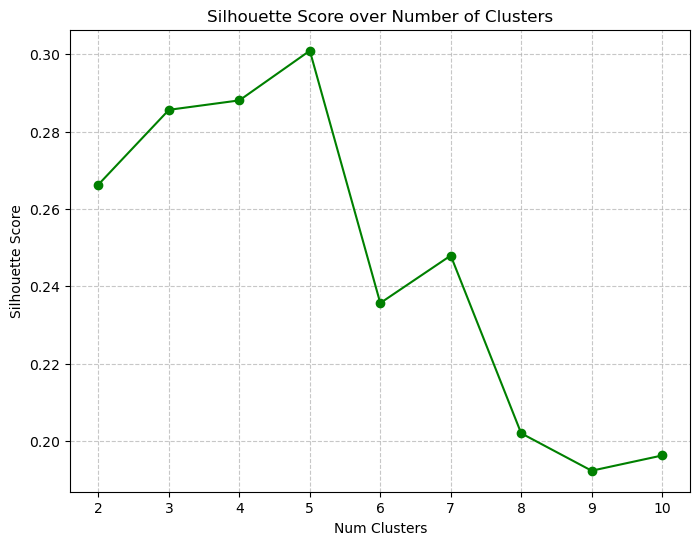

In [38]:
# Creating our range of numbers of clusters, [2,10] to iterate through and empty lists to store our scores
cluster_range = [2,3,4,5,6,7,8,9,10]
silhouette_scores = []
sse_scores = []

for cluster in cluster_range:
    # random_state fixes the starting centroids so results stay the same every run
    kmeans = KMeans(n_clusters=cluster, random_state=42)
    df_clusters = kmeans.fit_predict(df_scaled)

    # Calculating silhouette score
    sil_score = silhouette_score(df_scaled, df_clusters)
    silhouette_scores.append(sil_score)

    # SSE: how close countries are to their cluster center (sklearn calls this inertia_)
    sse_scores.append(kmeans.inertia_)

# Plotting silhouette scores against the number of clusters
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, silhouette_scores, 'go-')
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score over Number of Clusters')
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Observations of Silhouette Score Plot:**

<ul>
  <li>The silhouette score is highest at k = 5 (about 0.30), followed closely by k = 4 (about 0.29) and k = 3 (about 0.29). The difference between these three values is very small, so the silhouette score alone does not clearly point to one best number of clusters.</li>
  <li>All scores fall between about 0.19 and 0.30. Since a score near 0 means points sit close to the boundary between clusters, this tells us the clusters overlap quite a bit. This is expected for country data, since countries do not fall into neat groups but range gradually from less developed to more developed.</li>
  <li>After k = 5, the score drops sharply to about 0.24 at k = 6 and continues falling to below 0.20 by k = 9. This suggests that splitting the data into more than 5 clusters creates groups that are too small or too similar to each other.</li>
  <li>The line is not smooth. For example, the score rises again slightly at k = 7 before dropping. This matches the lecture point that silhouette scores do not always follow a steady pattern, which is why other methods are also needed to choose k.</li>
  <li>Before adding random_state = 42, k = 4 had the highest score and k = 5 scored about 0.26. After fixing the random starting centroids, k = 5 rose to about 0.30 while k = 3 and k = 4 stayed the same. This shows that results with more clusters are more sensitive to the random starting points, and fixing random_state was necessary to get consistent results.</li>
</ul>

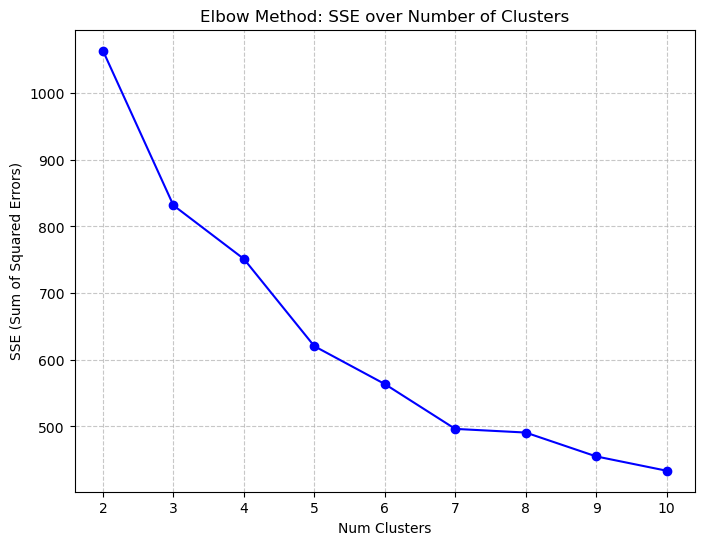

In [39]:
# Elbow method: plotting SSE against the number of clusters
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, sse_scores, 'bo-')
plt.xlabel('Num Clusters')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method: SSE over Number of Clusters')
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Observations of Elbow Plot:**

<ul>
  <li>SSE decreases as the number of clusters increases, which is expected. More clusters means smaller groups, so countries are closer to their cluster center.</li>
  <li>The largest drop happens between k = 2 and k = 3, where SSE falls from about 1,060 to about 830. After k = 3, the drops become noticeably smaller, which makes k = 3 the clearest elbow point.</li>
  <li>The curve is not a perfectly clean elbow. The drop from k = 4 to k = 5 (about 130) is larger than the drop from k = 3 to k = 4 (about 80), so there is a smaller second bend around k = 5. This matches the lecture point that the elbow is not always clearly defined.</li>
  <li>From k = 7 onward, the line almost flattens, with only about a 5 point drop between k = 7 and k = 8. Adding clusters beyond this point gives very little improvement.</li>
  <li>The elbow method points most clearly to k = 3, while the silhouette score was highest at k = 5. Since the two methods do not fully agree, we compare cluster sizes and what each cluster represents before choosing the final model.</li>
</ul>

In [40]:
# Comparing cluster sizes for the top candidates before choosing the final k
for k in [3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(df_scaled)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"k = {k}: cluster sizes = {sizes}")

k = 3: cluster sizes = [86, 36, 45]
k = 4: cluster sizes = [86, 36, 44, 1]
k = 5: cluster sizes = [87, 32, 44, 1, 3]


### **Observations of Cluster Size Comparison:**

<ul>
  <li>With k = 3, the countries are split into three groups of 86, 36, and 45 countries. All three clusters are large enough to represent meaningful groups of countries.</li>
  <li>With k = 4, the clusters are 86, 36, 44, and 1. The fourth cluster contains only a single country, and the only other change is one country moving out of the 45-country cluster. Instead of finding a new group, the model separated one outlier country from the rest.</li>
  <li>With k = 5, the clusters are 87, 32, 44, 1, and 3. The single-country cluster remains, and a new cluster of only 3 countries appears. These very small clusters are likely made up of extreme values, such as the outliers seen in inflation and exports in the pairplot.</li>
  <li>This explains why k = 4 and k = 5 had slightly higher silhouette scores. Placing a few extreme countries in their own clusters makes those countries very well separated, which raises the score, but it does not create groups that are useful for deciding how to distribute aid.</li>
  <li>Based on this comparison, adding clusters beyond k = 3 mainly isolates outliers rather than revealing new meaningful groups of countries.</li>
</ul>

In [41]:
# Final model: k = 3 chosen based on the elbow plot, silhouette scores, and cluster size comparison
best_k = 3
best_model = KMeans(n_clusters=best_k, random_state=42)

# Fit the final model and get the cluster label for each country
cluster_labels = best_model.fit_predict(df_scaled)

# Combine the original (unscaled) data, country names, and cluster labels into one table
df_results = df.copy()
df_results['country'] = countries
df_results['cluster'] = cluster_labels

# Check that cluster sizes match the comparison above
print(df_results['cluster'].value_counts().sort_index())
df_results.head()

cluster
0    86
1    36
2    45
Name: count, dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country,cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,Afghanistan,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,Albania,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,Algeria,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,Angola,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,Antigua and Barbuda,0


In [42]:
# Average value of each feature within each cluster, to understand what each group represents
cluster_profile = df_results.groupby('cluster').mean(numeric_only=True).round(2)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


### **Observations of each clusters:**

<ul>
  <li>Cluster 2 (45 countries) has the weakest health and economic conditions. It has the highest average child mortality at 95.11 deaths per 1,000 births, the lowest income at 3,539.84, the lowest GDP per capita at 1,766.71, and the lowest life expectancy at 59.06 years. It also has the highest fertility rate at 5.07 children per woman and the highest inflation at 11.99%. These are the countries most likely to need aid.</li>
  <li>Cluster 1 (36 countries) has the strongest conditions. Child mortality averages only 5.00, income is 45,672.22, GDP per capita is 42,494.44, and life expectancy is 80.13 years. It also has the lowest inflation at 2.67% and the highest health spending at 8.81% of GDP. These are developed countries.</li>
  <li>Cluster 0 (86 countries) sits between the other two on almost every feature, with child mortality of 22.46, income of 12,321.74, GDP per capita of 6,461.77, and life expectancy of 72.57 years. These are developing countries, and it is the largest group, which makes sense since most countries in the world fall between very low and very high development.</li>
  <li>The gaps between clusters are large. Child mortality in Cluster 2 is about 19 times higher than in Cluster 1, GDP per capita in Cluster 1 is about 24 times higher than in Cluster 2, and there is a difference of about 21 years in life expectancy. This shows the three clusters represent clearly different levels of development.</li>
  <li>Health spending is similar between Cluster 0 (6.25%) and Cluster 2 (6.30%). Since this column is a percentage of GDP, and Cluster 2 has a much lower GDP per capita, the actual amount spent on healthcare per person in Cluster 2 is much smaller.</li>
  <li>Exports follow the same order as development, rising from 28.60% in Cluster 2 to 40.27% in Cluster 0 and 58.74% in Cluster 1. This matches the positive relationship between exports and income seen in the heatmap.</li>
</ul>

### **Choosing the Best Number of Clusters:**

We selected **k = 3** as our best model. The decision was based on four criteria:

<ul>
  <li><b>Elbow method:</b> The largest drop in SSE happens between k = 2 and k = 3. After k = 3, the drops become much smaller, making k = 3 the clearest elbow point.</li>
  <li><b>Silhouette score:</b> k = 5 had the highest score (about 0.30), but k = 3 (about 0.29) was very close. Since the difference is small, the silhouette score alone was not enough to choose between them. All scores were around 0.3 or lower, which shows the clusters overlap, as expected for countries that range gradually in development.</li>
  <li><b>Cluster sizes:</b> With k = 4 and k = 5, the extra clusters contained only 1 and 3 countries. These small clusters isolate outliers rather than forming meaningful groups, which also explains their slightly higher silhouette scores. With k = 3, all clusters are a reasonable size (86, 36, and 45 countries).</li>
  <li><b>Usefulness for aid:</b> The three clusters represent clear levels of development: least developed, developing, and developed countries. This grouping is simple and directly useful for HELP International, since it clearly identifies the group of countries most in need of funding.</li>
</ul>

Although k = 3 did not have the highest silhouette score, it is supported by the elbow method, produces meaningful and reasonably sized clusters, and is the most practical choice for deciding how to allocate aid.

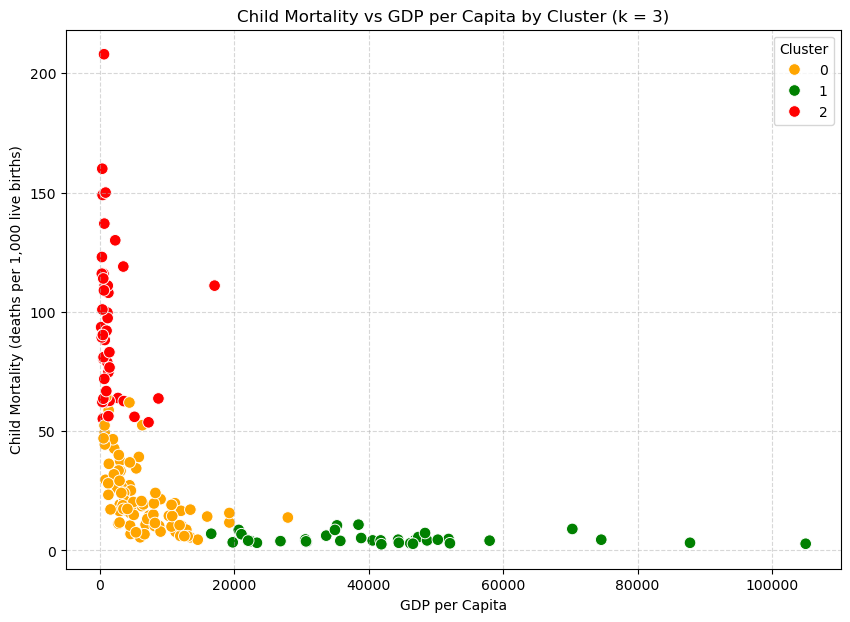

In [43]:
# Scatter plot of GDP per capita vs child mortality, colored by cluster
# Colors: red = least developed (2), orange = developing (0), green = developed (1)
cluster_colors = {0: 'orange', 1: 'green', 2: 'red'}

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_results, x='gdpp', y='child_mort', hue='cluster', palette=cluster_colors, s=70)
plt.xlabel('GDP per Capita')
plt.ylabel('Child Mortality (deaths per 1,000 live births)')
plt.title(f'Child Mortality vs GDP per Capita by Cluster (k = {best_k})')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **Observations of Scatter Plot:**

<ul>
  <li>The three clusters are clearly visible. Cluster 2 (red) forms a tall column on the far left, with very low GDP per capita and child mortality ranging from about 50 to over 200. Cluster 0 (orange) sits in the bottom-left, with GDP per capita mostly below 20,000 and child mortality mostly below 50. Cluster 1 (green) spreads along the bottom right, with GDP per capita above 20,000 and child mortality close to zero.</li>
  <li>The plot shows the same L-shaped pattern seen in the pairplot. Child mortality falls sharply as GDP per capita rises from very low levels, then flattens out. Once countries reach moderate wealth, further increases in GDP make little difference to child mortality.</li>
  <li>There is some overlap between clusters. Red and orange points mix where child mortality is around 50 to 65, and orange and green points mix where GDP per capita is around 15,000 to 28,000. This matches the low silhouette scores, and shows that countries change gradually from one level of development to the next rather than falling into completely separate groups.</li>
  <li>Some points appear to be in the "wrong" cluster on this plot. For example, one red point has a GDP per capita of about 17,000 but child mortality of about 111. This happens because K-Means grouped countries using all nine features, not just these two. A country can have moderate GDP but still be grouped with the least developed countries because of its other features, such as low life expectancy or high fertility.</li>
  <li>Most points are crowded on the left side of the plot because GDP per capita is heavily skewed. A small number of very wealthy countries stretch the x-axis to over 100,000, which compresses the differences between lower income countries.</li>
</ul>

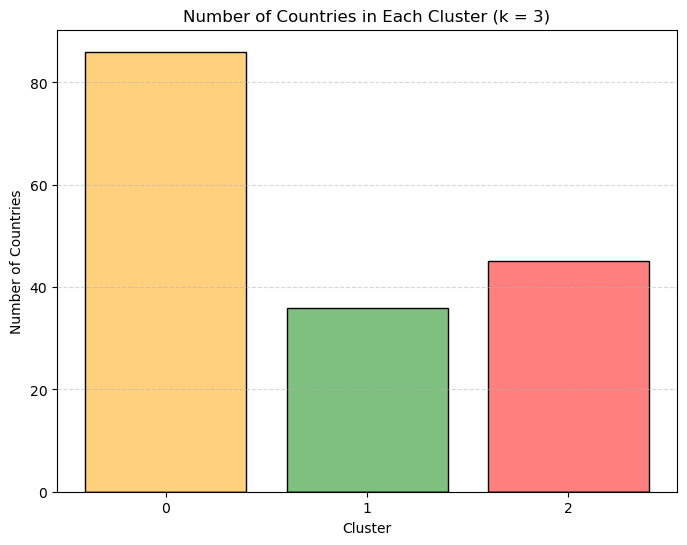

cluster
0    86
1    36
2    45
Name: count, dtype: int64


In [44]:
# Histogram showing how many countries are in each cluster
# Same colors as the scatter plot: red = least developed (2), orange = developing (0), green = developed (1)
plt.figure(figsize=(8, 6))
sns.histplot(data=df_results, x='cluster', hue='cluster', palette=cluster_colors, discrete=True, shrink=0.8, legend=False)
plt.xlabel('Cluster')
plt.ylabel('Number of Countries')
plt.title(f'Number of Countries in Each Cluster (k = {best_k})')
plt.xticks(range(best_k))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Print exact counts for each cluster
print(df_results['cluster'].value_counts().sort_index())

### **Observations of Cluster Size Histogram:**

<ul>
  <li>Cluster 0 (developing countries) is the largest group with 86 countries, which is about 51% of the dataset. Cluster 2 (least developed countries) has 45 countries, about 27%, and Cluster 1 (developed countries) is the smallest with 36 countries, about 22%.</li>
  <li>These sizes make sense in the real world. Most countries are neither very poor nor very wealthy, so it is expected that the middle group is the largest. Fewer countries reach the high income and health levels seen in Cluster 1.</li>
  <li>No cluster is extremely small or extremely large. The smallest cluster still contains 36 countries, so none of the groups are made up of just a few outliers, unlike the 1 and 3 country clusters that appeared with k = 4 and k = 5. This supports k = 3 as a meaningful choice.</li>
  <li>The clusters are not equal in size, and they do not need to be. K-Means groups countries based on how similar they are, not to create evenly sized groups, so uneven sizes reflect real differences in development between countries.</li>
  <li>Cluster 2 contains 45 countries. For HELP International, this is a manageable number to focus on when allocating funds, and it can be narrowed further by ranking countries within this cluster based on need.</li>
</ul>

### **3.3 Interpretation and cluster ranking**  

#### 3.3-A: Countries in each cluster

In [45]:
# What: prints the alphabetical list of countries in each cluster.
# Why: lets us check whether the groupings make sense using real-world knowledge.
for c in sorted(df_results['cluster'].unique()):
    members = sorted(df_results.loc[df_results['cluster'] == c, 'country'])
    print(f"\nCluster {c} ({len(members)} countries):")
    print(", ".join(members))


Cluster 0 (86 countries):
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Iraq, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithuania, Macedonia, FYR, Malaysia, Maldives, Mauritius, Micronesia, Fed. Sts., Moldova, Mongolia, Montenegro, Morocco, Myanmar, Nepal, Oman, Panama, Paraguay, Peru, Philippines, Poland, Romania, Russia, Samoa, Saudi Arabia, Serbia, Seychelles, Solomon Islands, Sri Lanka, St. Vincent and the Grenadines, Suriname, Tajikistan, Thailand, Tonga, Tunisia, Turkey, Turkmenistan, Ukraine, Uruguay, Uzbekistan, Vanuatu, Venezuela, Vietnam

Cluster 1 (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, C

**Observations of Countries in Each Cluster:**  

- **Cluster 0 (86 countries)** is mostly middle-income countries
- **Cluster 1 (36 countries)** is wealthy countries
- **Cluster 2 (45 countries)** is mostly African countries, along with Afghanistan, Haiti, Kiribati, Lao, Pakistan, Timor-Leste, and Yemen.

#### 3.3-B: Check against World Bank / UN data

In [46]:
import requests

# What: downloads the current World Bank income group for every country.
# Why: gives an official classification to compare the clusters against.
resp = requests.get("https://api.worldbank.org/v2/country",
                    params={"format": "json", "per_page": 400}, timeout=30)
income_lookup = {c['name']: c['incomeLevel']['value']
                 for c in resp.json()[1] if c['region']['value'] != 'Aggregates'}

# What: matches dataset names to World Bank spellings and adds each country's income group.
# Why: some names are spelled differently and would otherwise be missed.
name_map = {
    'Bahamas': 'Bahamas, The', 'Brunei': 'Brunei Darussalam', 'Cape Verde': 'Cabo Verde',
    'Czech Republic': 'Czechia', 'Egypt': 'Egypt, Arab Rep.', 'Gambia': 'Gambia, The',
    'Iran': 'Iran, Islamic Rep.', 'Lao': 'Lao PDR', 'Macedonia, FYR': 'North Macedonia',
    'Russia': 'Russian Federation', 'South Korea': 'Korea, Rep.', 'Turkey': 'Turkiye',
    'Venezuela': 'Venezuela, RB', 'Yemen': 'Yemen, Rep.', 'Vietnam': 'Viet Nam'
}
df_results['income_group'] = df_results['country'].replace(name_map).map(income_lookup)

# What: marks which countries are on the UN list of 44 least developed countries (LDCs).
# Why: adds a second real-world source based on development, not just income.
un_ldc = [
    'Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Burkina Faso', 'Burundi', 'Cambodia',
    'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Djibouti', 'Eritrea',
    'Ethiopia', 'Gambia', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kiribati', 'Lao', 'Lesotho',
    'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Myanmar', 'Nepal',
    'Niger', 'Rwanda', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Sudan',
    'Sudan', 'Timor-Leste', 'Togo', 'Tuvalu', 'Uganda', 'Tanzania', 'Yemen', 'Zambia'
]
df_results['un_ldc'] = df_results['country'].isin(un_ldc)

# What: counts how each cluster lines up with the income groups and the LDC list.
# Why: shows whether the clusters agree with real-world classifications.
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
print("World Bank income group by cluster:")
print(pd.crosstab(df_results['cluster'], df_results['income_group']).reindex(columns=income_order, fill_value=0))

print("\nUN least developed countries by cluster:")
print(df_results.groupby('cluster')['un_ldc'].agg(LDCs='sum', total='count'))

World Bank income group by cluster:
income_group  Low income  Lower middle income  Upper middle income  \
cluster                                                              
0                      0                   17                   49   
1                      0                    0                    0   
2                     20                   22                    3   

income_group  High income  
cluster                    
0                      20  
1                      36  
2                       0  

UN least developed countries by cluster:
         LDCs  total
cluster             
0           5     86
1           0     36
2          34     45


**Observations of Real-World Comparison:**  

- **Cluster 2:** 34 of 45 countries are UN least developed countries (LDC), 42 are World Bank low or lower-middle income, and none are high income.
- **Cluster 1:** All 36 countries are World Bank high income, and none are LDCs.
- **Cluster 0:** Mostly upper-middle income (48) or lower-middle income ([17 or 18]), with 5 LDCs and 20 high-income countries.
- The clusters closely match real-world development classifications.

#### 3.3-C: Rank clusters from most to least in need

In [47]:
# What: ranks the clusters by average child mortality and labels them.
# Why: identifies which cluster needs aid most, using the data instead of assuming what the cluster numbers mean.
need_order = cluster_profile['child_mort'].sort_values(ascending=False).index.tolist()
cluster_names = dict(zip(need_order, ['Least developed', 'Developing', 'Developed']))
df_results['development_level'] = df_results['cluster'].map(cluster_names)

# What: stores the most-in-need cluster and its countries.
# Why: the funding decision in 3.4 only uses these countries.
aid_cluster = need_order[0]
aid_countries = df_results[df_results['cluster'] == aid_cluster].copy()

print(cluster_names)
print(f"Cluster most in need of aid: {aid_cluster} ({len(aid_countries)} countries)")
cluster_profile.loc[need_order]

{2: 'Least developed', 0: 'Developing', 1: 'Developed'}
Cluster most in need of aid: 2 (45 countries)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44


**Summary of 3.3:**

- **Ranking (most to least in need):** Cluster 2 (least developed), Cluster 0 (developing), Cluster 1 (developed). The same order holds for child mortality, income, GDP per capita, life expectancy, and fertility.
- **Gap between clusters:** Cluster 2 has an average child mortality of 95.11 vs. 5.00 in Cluster 1, GDP per capita of 1,766.71 vs. 42,494.44, and life expectancy of 59.06 vs. 80.13 years.
- **Real-world check:** 34 of the 45 Cluster 2 countries are UN least developed countries, and all 36 Cluster 1 countries are World Bank high income, so the clusters match real-world classifications.
- **Target group:** HELP International should focus on the 45 countries in Cluster 2.

### 3.4 Funding decision and justification

#### 3.4-A: Need score ranking

In [52]:
# What: sets whether a higher or lower value means more need for each feature (exports and imports are left out).
# Why: the score must know that high child mortality is bad but high life expectancy is good.
need_direction = {
    'child_mort': 1, 'total_fer': 1, 'inflation': 1,
    'life_expec': -1, 'income': -1, 'gdpp': -1, 'health': -1
}

# What: ranks each country within the cluster on each feature as a percentile from 0 to 1.
# Why: puts all features on the same scale, so extreme values don't dominate.
ranks = pd.DataFrame(index=aid_countries.index)
for col, direction in need_direction.items():
    ranks[col] = aid_countries[col].rank(pct=True, ascending=(direction == 1))

# What: averages the percentiles into one need score and sorts countries from most to least in need.
# Why: 45 countries are too many to fund, so this shows which need help most.
aid_countries['need_score'] = ranks.mean(axis=1).round(3)
aid_ranked = aid_countries.sort_values('need_score', ascending=False).reset_index(drop=True)
aid_ranked.index += 1

aid_ranked[['country', 'need_score'] + list(need_direction)].head(10)

,country,need_score,child_mort,total_fer,inflation,life_expec,income,gdpp,health
1,"Congo, Dem. Rep.",0.789,116.0,6.54,20.80,57.5,609,334,7.91
2,Central African Republic,0.744,149.0,5.21,2.01,47.5,888,446,3.98
3,Niger,0.724,123.0,7.49,2.55,58.8,814,348,5.16
4,Mozambique,0.721,101.0,5.56,7.64,54.5,918,419,5.21
5,Sierra Leone,0.698,160.0,5.20,17.20,55.0,1220,399,13.10
6,Burundi,0.695,93.6,6.26,12.30,57.7,764,231,11.60
7,Guinea,0.692,109.0,5.34,16.10,58.0,1190,648,4.93
8,Chad,0.689,150.0,6.59,6.39,56.5,1930,897,4.53
9,Malawi,0.686,90.5,5.31,12.10,53.1,1030,459,6.59
10,Burkina Faso,0.633,116.0,5.87,6.81,57.9,1430,575,6.74


**Observations of Need Score Ranking:**

- Each Cluster 2 country was scored from 0 to 1 by averaging its percentile rank on seven indicators, where 1 means the most need.
- The ten highest-ranked countries are Congo (Dem. Rep.), Central African Republic, Niger, Mozambique, Sierra Leone, Burundi, Guinea, Chad, Malawi, and Burkina Faso, with need scores from 0.789 to 0.633.
- All ten are in sub-Saharan Africa, and all ten are on the UN list of least developed countries.
- **Congo (Dem. Rep.)** ranks highest (0.789). It has the lowest income in the entire dataset (609), a very low GDP per capita (334), high child mortality (116), a high fertility rate (6.54), and high inflation (20.8%).
- **Central African Republic** ranks second (0.744). It has the lowest life expectancy in the top 10 (47.5 years) and very high child mortality (149), and it spends only 3.98% of GDP on health.
- Other countries rank high because of one especially severe indicator: Niger has the highest fertility rate in the dataset (7.49), Burundi has the lowest GDP per capita in the dataset (231), and Sierra Leone has the highest child mortality in the top 10 (160).
- No country ranks high because of a single extreme value alone. Each of the top 10 has poor values across several indicators, which is the purpose of combining seven features.
- Some countries have scores lowered by one better indicator. Sierra Leone (13.1%) and Burundi (11.6%) spend a high share of GDP on health, and Chad has a relatively higher income (1,930) and GDP per capita (897), even though Chad's child mortality (150) is among the highest.
- The scores for ranks 2 to 9 are very close (0.744 to 0.686), so these countries have a similar level of need. The largest gap is between Malawi (0.686) and Burkina Faso (0.633), and Congo (Dem. Rep.) stands slightly above the rest.

#### 3.4-B: Budget Allocation

In [55]:
# What: selects the 10 highest-ranked countries and sets the budget.
# Why: these are the countries that will receive the $100 million in funds.
top_n = 10
budget = 100_000_000
funding = aid_ranked.head(top_n)[['country', 'need_score', 'un_ldc', 'income_group']].copy()

# What: splits the budget in proportion to each country's need score.
# Why: answers "how much" with a clear rule, so countries with more need get more money.
funding['share_%'] = (funding['need_score'] / funding['need_score'].sum() * 100).round(1)
funding['allocation_$'] = (funding['need_score'] / funding['need_score'].sum() * budget).round(0).astype(int)

print(f"Total allocated: ${funding['allocation_$'].sum():,.0f}")
funding

Total allocated: $100,000,001


,country,need_score,un_ldc,income_group,share_%,allocation_$
1,"Congo, Dem. Rep.",0.789,True,Low income,11.2,11158252
2,Central African Republic,0.744,True,Low income,10.5,10521850
3,Niger,0.724,True,Low income,10.2,10239004
4,Mozambique,0.721,True,Low income,10.2,10196578
5,Sierra Leone,0.698,True,Low income,9.9,9871305
6,Burundi,0.695,True,Low income,9.8,9828879
7,Guinea,0.692,True,Lower middle income,9.8,9786452
8,Chad,0.689,True,Low income,9.7,9744025
9,Malawi,0.686,True,Low income,9.7,9701598
10,Burkina Faso,0.633,True,Low income,9.0,8952058


**Observations of Budget Allocation:**

- The $100,000,000 budget was divided among the 10 highest-ranked countries in proportion to their need scores.
- The largest allocation goes to **Congo (Dem. Rep.)** ($11,158,252, 11.2%), and the smallest goes to **Burkina Faso** ($8,952,058, 9.0%). The difference between them is $2,206,194.
- Because the need scores are close together, the allocation is close to an even split. An equal split would give each country $10,000,000. The top four countries (Congo, Central African Republic, Niger, and Mozambique) receive slightly more than that, and the other six receive slightly less.
- All 10 countries are UN least developed countries.
- 9 of the 10 are World Bank low-income countries. The only exception is Guinea, which is lower-middle income, but its child mortality (109) and low life expectancy (58.0) still place it among the countries most in need.
- This confirms that the funds go to countries also recognized as among the poorest by real-world classifications.

### Final Recommendation:

HELP International should divide its $100,000,000 among the following 10 countries in proportion to their need scores:

| Rank | Country | Need score | Share | Allocation |
|---|---|---|---|---|
| 1 | Congo, Dem. Rep. | 0.789 | 11.2% | $11,158,252 |
| 2 | Central African Republic | 0.744 | 10.5% | $10,521,850 |
| 3 | Niger | 0.724 | 10.2% | $10,239,004 |
| 4 | Mozambique | 0.721 | 10.2% | $10,196,578 |
| 5 | Sierra Leone | 0.698 | 9.9% | $9,871,305 |
| 6 | Burundi | 0.695 | 9.8% | $9,828,879 |
| 7 | Guinea | 0.692 | 9.8% | $9,786,452 |
| 8 | Chad | 0.689 | 9.7% | $9,744,025 |
| 9 | Malawi | 0.686 | 9.7% | $9,701,598 |
| 10 | Burkina Faso | 0.633 | 9.0% | $8,952,058 |

**Justification:**
- **Why Cluster 2:** It has the worst health and economic indicators of the three clusters, and 34 of its 45 countries are UN least developed countries.
- **Why these 10:** They have the highest need scores in Cluster 2, which combine seven health and economic indicators rather than income alone. Each has poor values across several indicators, such as very high child mortality, low life expectancy, and very low income.
- **Why these amounts:** Funds are split by need score, so countries with greater need receive more. Because the scores are close, each country receives between 9.0% and 11.2% of the budget, or about $9 million to $11 million.
- **Real-world agreement:** All 10 countries are UN least developed countries, and 9 are World Bank low-income countries.

**Limitations:**
- The data is a single snapshot and may not reflect current conditions.
- The features and equal weights in the need score were chosen by our group, and different choices could change the ranking.
- The score does not account for conflict or governance, which affect whether aid reaches the people who need it.
- Limiting funds to 10 countries leaves out other Cluster 2 countries that still have high need.

In [56]:
funding['allocation_$'] = (funding['need_score'] / funding['need_score'].sum() * budget).round(0).astype(int)